# Chapter 2: March 2023 Rolling Fork Tornado

```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

Next, title your notebook appropriately with a top-level Markdown header, `#` (see the very first cell above). Do not use this level header anywhere else in the notebook. Our book build process will use this title in the navbar, table of contents, etc. Keep it short, keep it descriptive. 

Follow this with a `---` cell to visually distinguish the transition to the prerequisites section.

---

# Overview
The tornado outbreak of March 24–27, 2023 was a devastating multi-day severe weather event that swept across the Southern United States, particularly impacting Mississippi, Alabama, Tennessee, and Georgia. Triggered by a slow-moving upper-level trough interacting with moist, unstable air from the Gulf of Mexico, the outbreak produced 35 confirmed tornadoes, including a violent EF4 that tore through Rolling Fork, Midnight, and Silver City, Mississippi with peak winds of 195 mph. This EF4 tornado alone caused catastrophic damage and multiple fatalities and brought tornado emergencies ahead of widespread destruction.<br>
Over the four-day span, the system also unleashed damaging straight-line winds, large hail, and flooding. In total, the outbreak resulted in 23 fatalities (plus two from non-tornadic causes), over 230 injuries, and an estimated $1.9 billion in damage. The event was notable not only for its intensity but also for its geographic breadth and the prolonged nature of the severe weather threat.

---

This chapter explores MRMS data from this tornado outbreak, specifically from the Rolling Fork–Silver City, MS tornado on March 24, 2023. The chapter investigates:  
 - Reflectivity  
 - Precipitation Rates  
 - Rotation  
 - Hail Swaths - *Under Construction!* 
 - Storm Intensity (Vertically integrated liquid) - *Under Construction!*

To support this analysis, the chapter introduces a practical method for accessing MRMS data directly from an AWS server. It guides readers through defining a map and customizing its spatial extent to filter and process data relevant to the event. By showcasing multiple variations of each MRMS variable, the chapter highlights the accessibility and versatility of these datasets for visualizing high-impact weather events. A focused case study on the Rolling Fork tornado illustrates how several hours of MRMS data can be leveraged to gain insight into storm properties of a significant weather event.

--- 

## Imports
This section brings in packages for handling AWS requests, manipulating MRMS files, and rendering plots on a map.

In [16]:
import datetime
import gzip
import io
import sys
import tempfile
import urllib

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import s3fs
import xarray
import xarray as xr

aws = s3fs.S3FileSystem(anon=True)

--- 

## Build Map
This section uses Cartopy to build a blank map then define our extent for our case study.

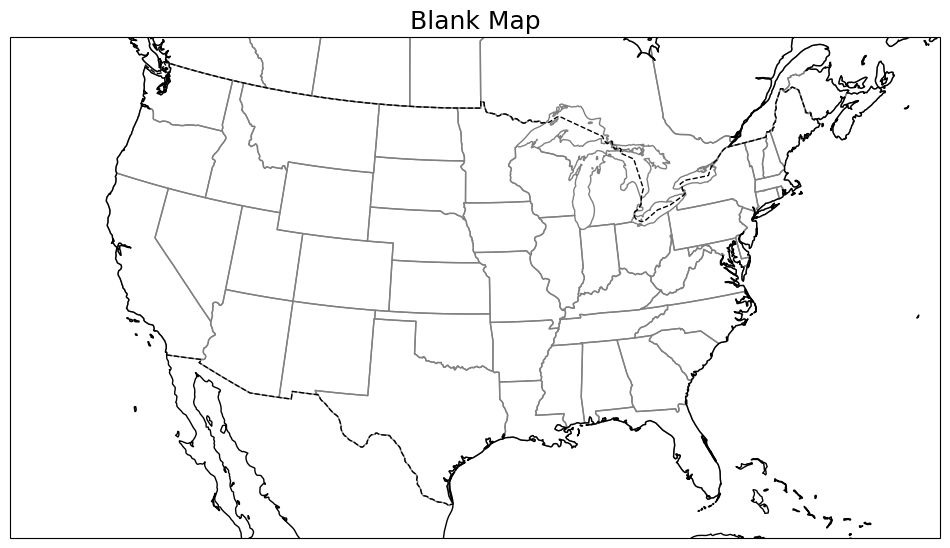

In [17]:
# Set up the map projection
projection = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": projection})

# Set extent for CONUS (approximate)
ax.set_extent([-125, -66.5, 24, 50], crs=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.STATES.with_scale("50m"), edgecolor="gray")
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle="--", edgecolor="black")
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))

# Optional: remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Add title
plt.title("Blank Map", fontsize=18)

plt.show()

#### We will be looking specifically at the tornado outbreak that occurred in Dixie Alley, so let's set our extents specifically to Dixie Alley. 

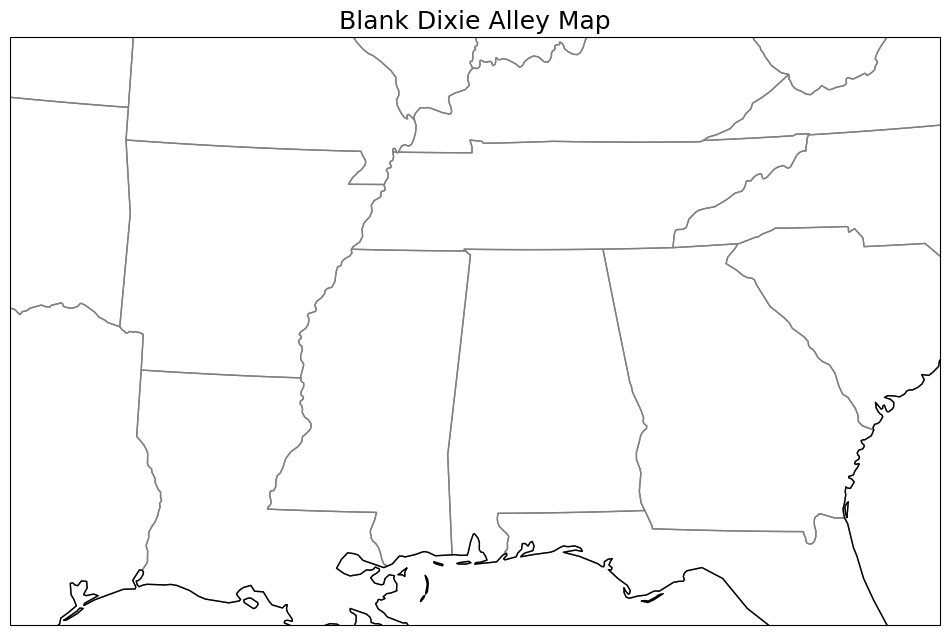

In [18]:
lon_min, lon_max = -96, -80
lat_min, lat_max = 29, 38

# Set up the map projection
projection = ccrs.LambertConformal(central_longitude=-88, central_latitude=34)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": projection})

# Set extent for CONUS (approximate)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.STATES.with_scale("50m"), edgecolor="gray")
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle="--", edgecolor="black")
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))

# Optional: remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Add title
plt.title("Blank Dixie Alley Map", fontsize=18)

plt.show()

In [19]:
def plot_mrms(
    data1, data2, title, cbar_label, mask_val=None, mask_leq=False, cmap="turbo"
):
    """Plot two time steps of an MRMS variable side by side.
    Uses lon_min, lon_max, lat_min, lat_max from notebook scope.
    """
    if mask_leq:
        masked1 = np.ma.masked_where(data1 <= 0, data1)
        masked2 = np.ma.masked_where(data2 <= 0, data2)
    elif mask_val is not None:
        masked1 = np.ma.masked_where(data1 == mask_val, data1)
        masked2 = np.ma.masked_where(data2 == mask_val, data2)
    else:
        masked1, masked2 = np.asarray(data1), np.asarray(data2)

    projection = ccrs.LambertConformal(central_longitude=-88, central_latitude=34)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 8),
        subplot_kw={"projection": projection},
        gridspec_kw={"bottom": 0.2},
    )
    meshes = []
    for ax, masked, data, label in zip(
        axes,
        [masked1, masked2],
        [data1, data2],
        ["(a) 3/26/2026 @ 21z", "(b) 3/26/2026 @ 22z"],
    ):
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.STATES.with_scale("50m"), edgecolor="gray")
        ax.add_feature(
            cfeature.BORDERS.with_scale("50m"), linestyle="--", edgecolor="black"
        )
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
        mesh = ax.pcolormesh(
            data.longitude,
            data.latitude,
            masked,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
            shading="auto",
        )
        ax.set_title(label, fontsize=15)
        meshes.append(mesh)
    cbar_ax = fig.add_axes([0.25, 0.25, 0.5, 0.02])
    cbar = fig.colorbar(meshes[0], cax=cbar_ax, orientation="horizontal")
    cbar.set_label(cbar_label)
    plt.suptitle(
        title,
        fontsize=20,
        x=0.5,
        y=0.85,
        horizontalalignment="center",
        verticalalignment="top",
    )
    plt.show()

---

## Fetch Data
#### This section uses s3 to pull in the data from the AWS s3 server. Following data acquisition, the module uses xarray to filter the resulting DataArray for the size of the desired map.
##### For variable names, see link *[here](https://noaa-mrms-pds.s3.amazonaws.com/index.html#CONUS/)*.

In [20]:
def find_available_files(variable: str, yyyymmdd: str, hh: str):

    files_list = []

    available_files = aws.ls(
        f"noaa-mrms-pds/CONUS/{variable}/{yyyymmdd}/", refresh=True
    )
    for file in available_files:
        file_hour = file[-15:-13]
        if file_hour == hh:
            files_list.append(file)

    if len(files_list) == 0:
        raise ValueError(f"No files found for {variable} on {yyyymmdd} at hour {hh}.")
    else:
        return files_list


def fetch_mrms_data(
    file: str,
    lon_min: float = None,
    lat_min: float = None,
    lon_max: float = None,
    lat_max: float = None,
):
    url = f"https://noaa-mrms-pds.s3.amazonaws.com/{file[14:]}"
    response = urllib.request.urlopen(url)
    compressed_file = response.read()
    with tempfile.NamedTemporaryFile(suffix=".grib2") as f:
        f.write(gzip.decompress(compressed_file))
        data_in = xr.load_dataarray(f.name, engine="cfgrib", decode_timedelta=True)

    # Optional spatial filtering
    if all(v is not None for v in [lon_min, lat_min, lon_max, lat_max]):
        data_in = data_in.sel(
            latitude=slice(lat_max, lat_min),  # descending order
            longitude=slice(360 - abs(lon_min), 360 - abs(lon_max)),
        )

    return data_in

---

# Case Study - March 24, 2023
### Rolling Fork - Silver City, MS Tornado
### 3/25/23 1z to 2z

In [21]:
# Lon mins and maxes for our projections:
lon_min, lon_max = -96, -80
lat_min, lat_max = 35, 50

##  Maximum 1-Hour Composite Reflectivity
##### The MRMS Max 1-Hour Composite Reflectivity product represents the highest reflectivity value observed within the past hour across all radar scans, providing a time-integrated view of storm intensity. It helps forecasters identify areas of persistent or intense convection, especially useful for tracking severe weather like hail or heavy rainfall. This product is derived from a seamless mosaic of multiple radars, quality-controlled to remove non-meteorological artifacts.
---

In [13]:
#### March 24, 2023 - Rolling Fork - Silver City, MS Tornado -- EF4, 71 minutes long, est winds 195 mph
## 3/25/23 1z to 2z, so we'll grab two hours of data shortly

In [39]:
# Grab 2 hours of data for plotting
cref1files = find_available_files("CREF_1HR_MAX_00.50", "20260326", "21")
cref1z = fetch_mrms_data(
    cref1files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

cref2files = find_available_files("CREF_1HR_MAX_00.50", "20260326", "22")
cref2z = fetch_mrms_data(
    cref2files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

# Mask fill values for both datasets

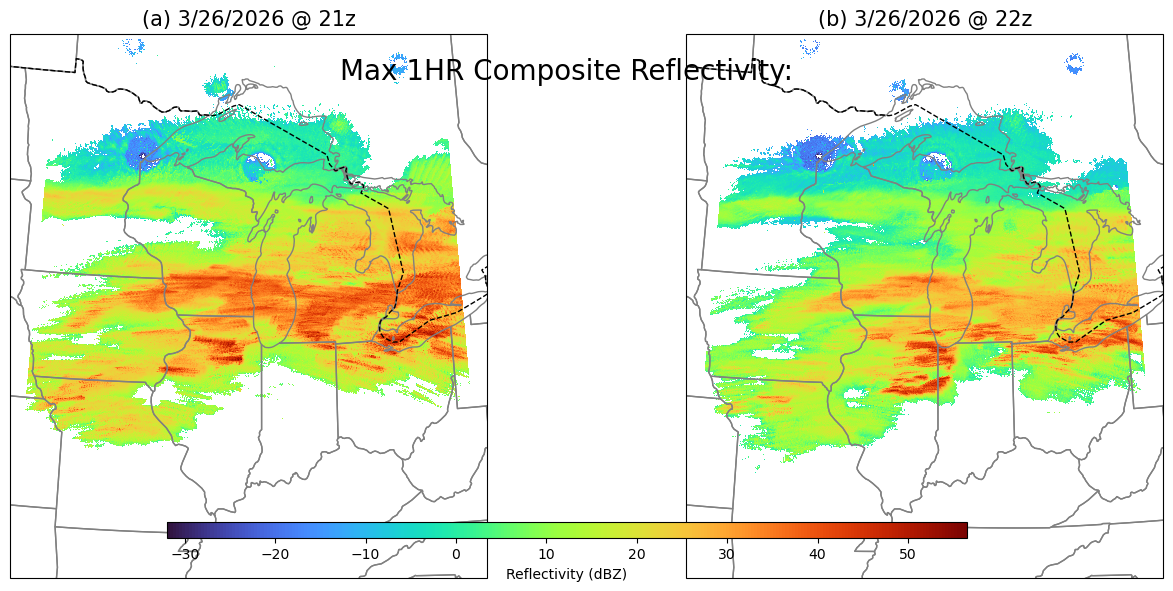

In [49]:
plot_mrms(
cref1z,
 cref2z,
 "Max 1HR Composite Reflectivity:",
  "Reflectivity (dBZ)",
  mask_val=-99.0,
)

---

## Surface Precip Rate
To describe Surface Precip Rate, there are three variables that can be used:

#### Surface Precipitation Rate Products

| Variable Name             | Description                                                                 | Temporal Resolution       | Filename Pattern                     |
|--------------------------|------------------------------------------------------------------------------|---------------------------|--------------------------------------|
| Instantaneous PrecipRate | - Estimates current rainfall intensity<br>- Derived from dual-pol radar     | - Every 2 minutes           | `PrecipRate_00.00`                   |
| MultiSensor QPE (Pass 1 & Pass 2) | - Combines radar and precip gauge data<br>- Available in 1-pass and 2-pass versions<br>- Used for hourly accumulation | - Hourly (Pass 1 and Pass 2) | `MRMS_QPE_01H_Pass1_00.00`           |
| RadarOnly QPE | - Estimates surface rainfall rate using dual-polarization radar reflectivity.<br>- Captures rapid changes in precipitation intensity at high temporal resolution. | - Every 2 minutes <br>- Available in 15 minute as well as (1, 3, 6, 12, 24, 48) hour intervals<br>- QPE since 12z also available | `RadarOnly_QPE_01H_00.00` |
--- 

### Instantaneous Precip Rate

In [41]:
precip1files = find_available_files("PrecipRate_00.00", "20260326", "21")  # Precip Rate
precip_1z = fetch_mrms_data(
    precip1files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
precip2files = find_available_files("PrecipRate_00.00", "20260326", "22")
precip_2z = fetch_mrms_data(
    precip2files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

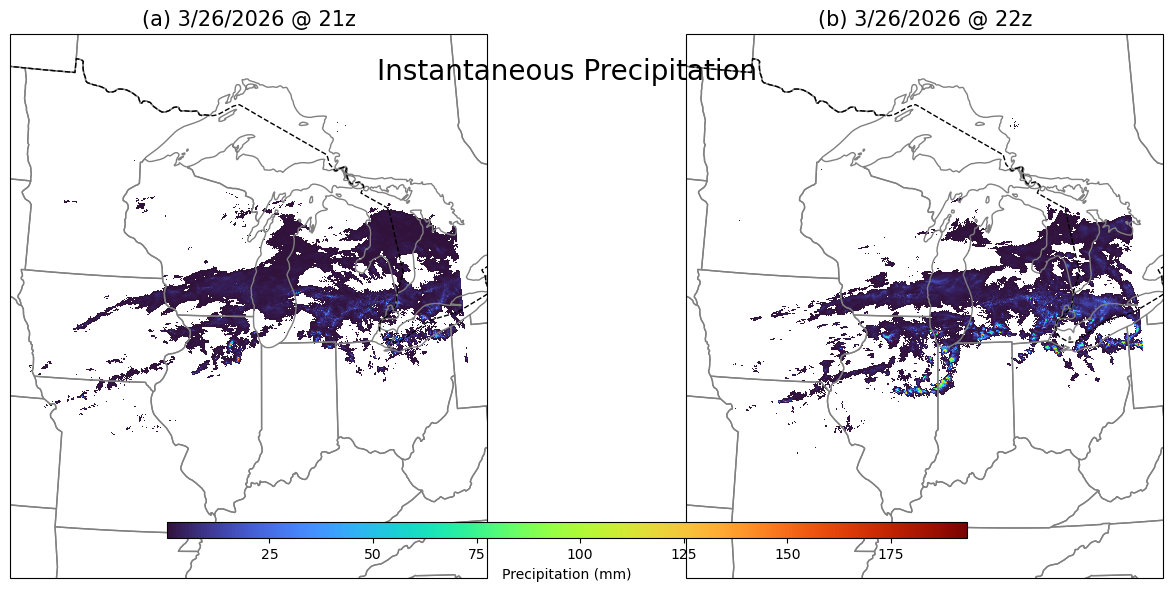

In [42]:
plot_mrms(
    precip_1z,
    precip_2z,
    "Instantaneous Precipitation",
    "Precipitation (mm)",
    mask_leq=True,
)

### MultiSensorQPE - 1 Hour - Pass 1

In [61]:
# MultiSensor_QPE_01H_Pass1_00.00
QPE1files = find_available_files(
    "MultiSensor_QPE_01H_Pass1_00.00", "20260326", "21"
)  # QPE: Quantified Precip Estimation - Offered hourly.
QPE_1z = fetch_mrms_data(
    QPE1files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
QPE2files = find_available_files("MultiSensor_QPE_01H_Pass1_00.00", "20260326", "22")
QPE_2z = fetch_mrms_data(
    QPE2files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

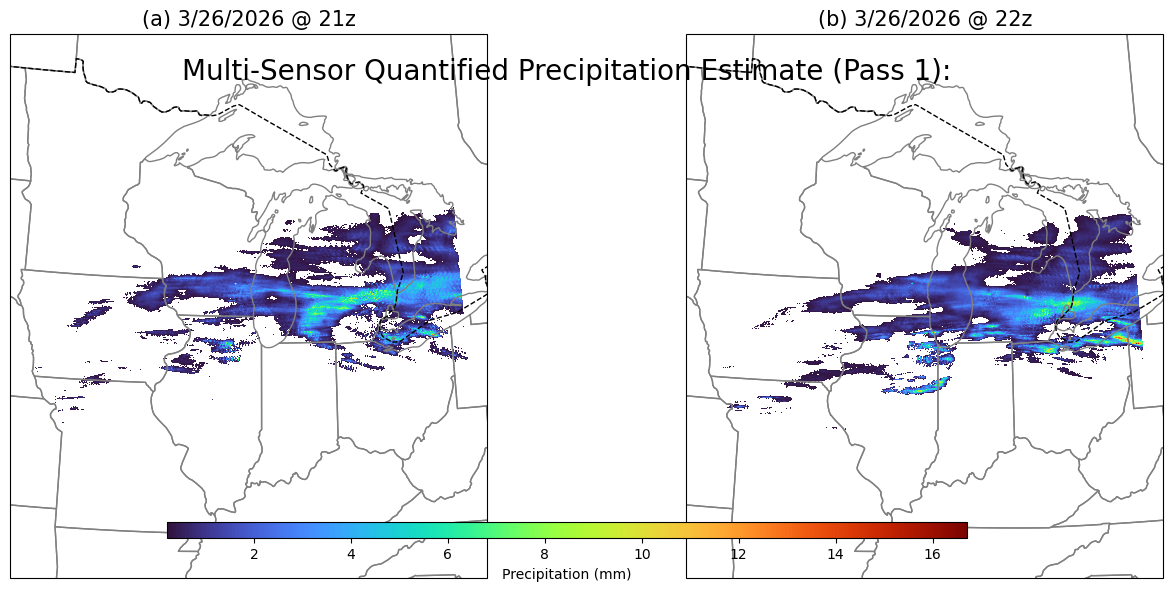

<Figure size 640x480 with 0 Axes>

In [63]:
plot_mrms(
    QPE_1z,
    QPE_2z,
    "Multi-Sensor Quantified Precipitation Estimate (Pass 1):",
    "Precipitation (mm)",
    mask_leq=True,
)

### MultiSensorQPE - 1 Hour - Pass 2

In [59]:
# MultiSensor_QPE_01H_Pass2_00.00
QPE1zp2files = find_available_files(
    "MultiSensor_QPE_01H_Pass2_00.00", "20260326", "21"
)  # QPE: Quantified Precip Estimation - last hour, 2nd pass
QPE_1z_p2 = fetch_mrms_data(
    QPE1zp2files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
QPE2files = find_available_files("MultiSensor_QPE_01H_Pass2_00.00", "20260326", "22")
QPE_2z_p2 = fetch_mrms_data(
    QPE2files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

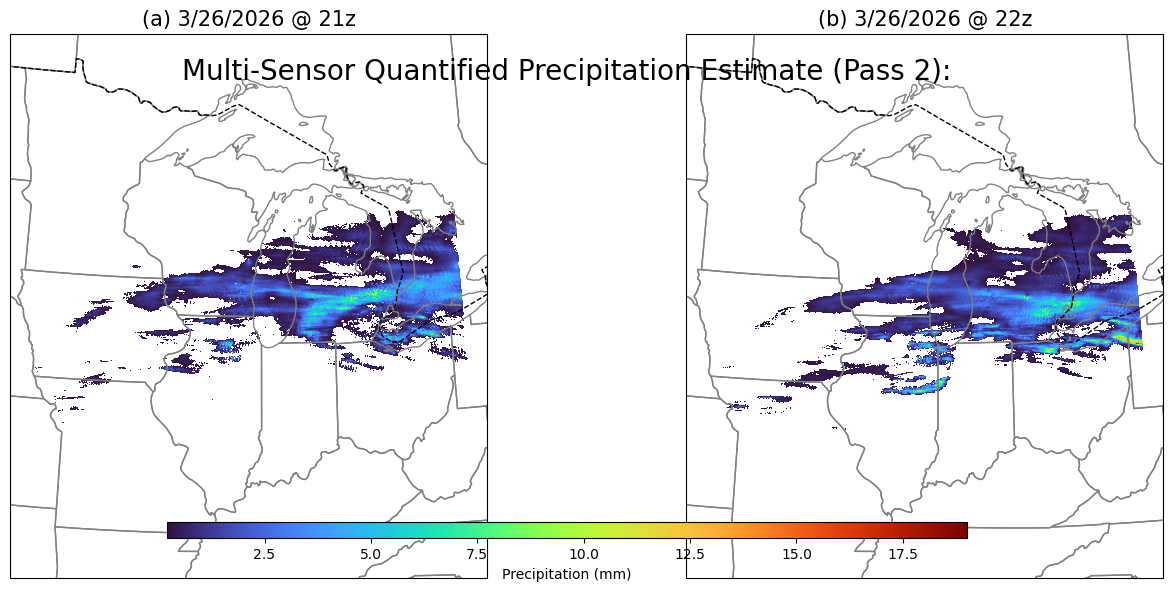

In [60]:
plot_mrms(
    QPE_1z_p2,
    QPE_2z_p2,
    "Multi-Sensor Quantified Precipitation Estimate (Pass 2):",
    "Precipitation (mm)",
    mask_leq=True,
)

### Radar Only QPE - Last Hour

In [47]:
RQPE1files = find_available_files(
    "RadarOnly_QPE_01H_00.00", "20260326", "21"
)  # RadarOnly_QPE: Radar Only Quantified Precip Estimation - last hour
RQPE_1z = fetch_mrms_data(
    RQPE1files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
RQPE2files = find_available_files("RadarOnly_QPE_01H_00.00", "20260326", "22")
RQPE_2z = fetch_mrms_data(
    RQPE2files[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

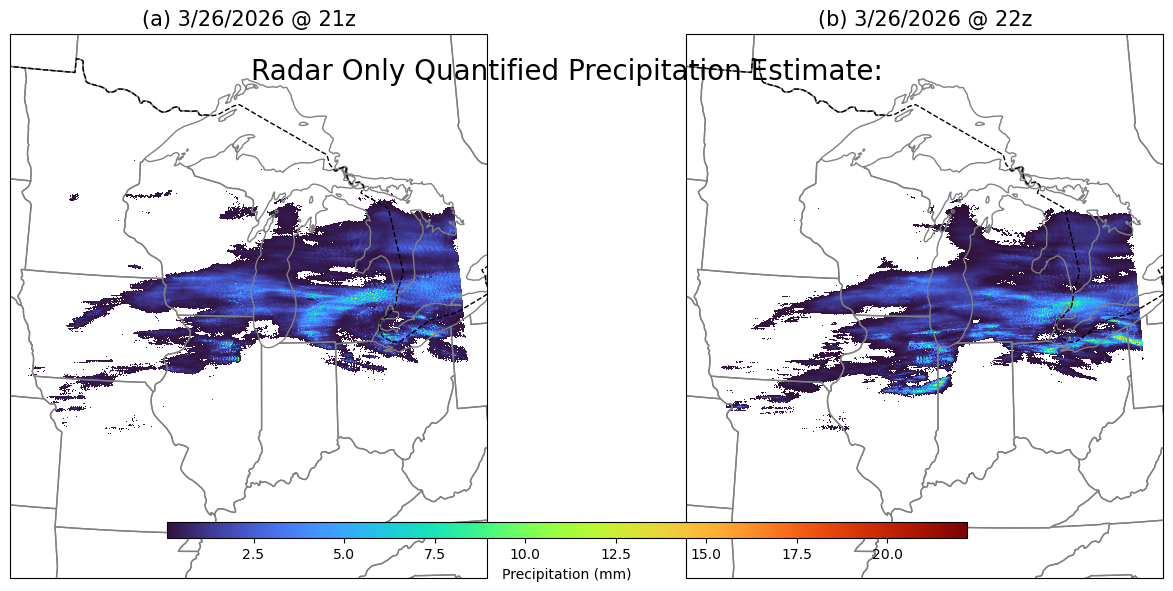

In [50]:
plot_mrms( RQPE_1z, RQPE_2z, "Radar Only Quantified Precipitation Estimate:", "Precipitation (mm)", mask_leq=True,)

---

## Rotation
#### These rotation products can be combined to assess both the intensity and persistence of storm-scale rotation across multiple atmospheric layers and time scales. By layering instantaneous azimuthal shear with rotation tracks—especially ML-enhanced versions—forecasters and researchers can better identify evolving mesocyclones, discriminate between transient and sustained rotation, and refine environmental risk assessments for severe weather.

| Variable                         | Description                                                                 | Temporal Resolution | Filename Pattern                          |
|----------------------------------|-----------------------------------------------------------------------------|----------------------|-------------------------------------------|
| Merged AzShear (0-2km AGL)     | Low-level azimuthal shear (0–2 km AGL); highlights near-surface rotation.  | Instantaneous        | MergedAzShear_0-2kmAGL_00.50              |
| Merged AzShear (3-6km AGL)     | Mid-level azimuthal shear (3–6 km AGL); captures elevated storm rotation.  | Instantaneous        | MergedAzShear_3-6kmAGL_00.50              |
| Rotation Track (30-min)         | 30-min accumulation of low-level rotation; useful for short-term tracking. | 30 minutes           | RotationTrack30min_00.50                  |
| Rotation Track (60-min)         | 60-min accumulation of low-level rotation; highlights sustained activity.  | 60 minutes           | RotationTrack60min_00.50                  |
| Rotation Track ML (30-min)       | ML-enhanced 30-min rotation track; filters noise, boosts confidence.       | 30 minutes           | RotationTrackML30min_00.50                |
| Rotation Track ML (60-min)       | ML-enhanced 60-min rotation track; detects short-lived intense rotation.   | 60 minutes           | RotationTrackML60min_00.50                |
 ---

### Merged AzShear (0-2km AGL)

In [ ]:
# MergedAzShear_0-2kmAGL_00.50
Azshrfiles1_2km = find_available_files(
    "MergedAzShear_0-2kmAGL_00.50", "20230325", "01"
)  # Merged AzShr (0-2km AGL)
Azshr_1z = fetch_mrms_data(
    Azshrfiles1_2km[0],
    lon_min=lon_min,
    lat_min=lat_min,
    lon_max=lon_max,
    lat_max=lat_max,
)
Azshrfiles2_2km = find_available_files("MergedAzShear_0-2kmAGL_00.50", "20230325", "02")
Azshr_2z = fetch_mrms_data(
    Azshrfiles2_2km[0],
    lon_min=lon_min,
    lat_min=lat_min,
    lon_max=lon_max,
    lat_max=lat_max,
)

In [ ]:
plot_mrms(
    Azshr_1z,
    Azshr_2z,
    "Merged AzShear (0-2km AGL):",
    "Azimuthal Shear (s^-1)",
    mask_leq=True,
)

### Merged AzShear (3-6 km AGL)

In [ ]:
# MergedAzShear_3-6kmAGL_00.50
Azshrfiles1_3km = find_available_files(
    "MergedAzShear_3-6kmAGL_00.50", "20230325", "01"
)  # Merged AzShr (3-6km AGL)
Azshr3_1z = fetch_mrms_data(
    Azshrfiles1_3km[0],
    lon_min=lon_min,
    lat_min=lat_min,
    lon_max=lon_max,
    lat_max=lat_max,
)
Azshrfiles2_3km = find_available_files("MergedAzShear_3-6kmAGL_00.50", "20230325", "02")
Azshr3_2z = fetch_mrms_data(
    Azshrfiles2_3km[0],
    lon_min=lon_min,
    lat_min=lat_min,
    lon_max=lon_max,
    lat_max=lat_max,
)

In [ ]:
plot_mrms(
    Azshr3_1z,
    Azshr3_2z,
    "Merged AzShear (3-6km AGL):",
    "Azimuthal Shear (s^-1)",
    mask_leq=True,
)

### Rotation Track (30-minute)

In [ ]:
# RotationTrack30min_00.50
RoTrack_30mFiles1 = find_available_files(
    "RotationTrack30min_00.50", "20230325", "01"
)  # Rotation Tracks (30-min)
RoTrack_30m_1z = fetch_mrms_data(
    RoTrack_30mFiles1[0],
    lon_min=lon_min,
    lat_min=lat_min,
    lon_max=lon_max,
    lat_max=lat_max,
)
RoTrack_30mFiles2 = find_available_files("RotationTrack30min_00.50", "20230325", "02")
RoTrack_30m_2z = fetch_mrms_data(
    RoTrack_30mFiles2[0],
    lon_min=lon_min,
    lat_min=lat_min,
    lon_max=lon_max,
    lat_max=lat_max,
)

In [ ]:
plot_mrms(
    RoTrack_30m_1z,
    RoTrack_30m_2z,
    "Rotation Track (30-minutes):",
    "Units",
    mask_leq=True,
)

### Rotation Track (60 minutes)

In [ ]:
# RotationTrack60min_00.50
RoTrack_60mFiles1 = find_available_files(
    "RotationTrack60min_00.50", "20230325", "01"
)  # Rotation Tracks (60-min)
RoTrack_60m_1z = fetch_mrms_data(
    RoTrack_60mFiles1[0],
    lon_min=lon_min,
    lat_min=lat_min,
    lon_max=lon_max,
    lat_max=lat_max,
)
RoTrack_60mFiles2 = find_available_files("RotationTrack60min_00.50", "20230325", "02")
RoTrack_60m_2z = fetch_mrms_data(
    RoTrack_60mFiles2[0],
    lon_min=lon_min,
    lat_min=lat_min,
    lon_max=lon_max,
    lat_max=lat_max,
)

In [ ]:
plot_mrms(
    RoTrack_60m_1z,
    RoTrack_60m_2z,
    "Rotation Track (Last 60-minutes):",
    "Units",
    mask_leq=True,
)

In [ ]:
# Coming soon:
# RotationTrackML60min_00.50 -  for the sake of time, hold on this
# RotationTrackML30min_00.50 -  for the sake of time, hold on this

---

### Hail Swaths

In [ ]:
# MESH_00.50 - Maximum Expected Size of Hail
MeshFiles1 = find_available_files("MESH_00.50", "20230325", "01")  # MESH
Mesh1z = fetch_mrms_data(
    MeshFiles1[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
MeshFiles2 = find_available_files("MESH_00.50", "20230325", "02")
Mesh2z = fetch_mrms_data(
    MeshFiles2[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

In [ ]:
plot_mrms(Mesh1z, Mesh2z, "Maximum Expected Size of Hail:", "Units", mask_leq=True)

### Severe Hail Index

In [ ]:
# SHI_00.50 - Severe Hail Index
SHIFiles1 = find_available_files("SHI_00.50", "20230325", "01")  # SHI
SHI1z = fetch_mrms_data(
    SHIFiles1[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
SHIFiles2 = find_available_files("SHI_00.50", "20230325", "02")
SHI2z = fetch_mrms_data(
    SHIFiles2[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

In [ ]:
plot_mrms(SHI1z, SHI2z, "Severe Hail Index:", "Units", mask_leq=True)

### Vertically Integrated Ice

In [ ]:
# VII_00.50 - Vertically Integrated Ice
VIIFiles1 = find_available_files("VII_00.50", "20230325", "01")
VII1z = fetch_mrms_data(
    VIIFiles1[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
VIIFiles2 = find_available_files("VII_00.50", "20230325", "02")
VII2z = fetch_mrms_data(
    VIIFiles2[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

In [ ]:
plot_mrms(VII1z, VII2z, "Vertically Integrated Ice:", "Units", mask_leq=True)

### Probability of Severe Hail

In [ ]:
# POSH_00.50
POSHFiles1 = find_available_files("POSH_00.50", "20230325", "01")
POSH1z = fetch_mrms_data(
    POSHFiles1[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
POSHFiles2 = find_available_files("POSH_00.50", "20230325", "02")
POSH2z = fetch_mrms_data(
    POSHFiles2[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

In [ ]:
plot_mrms(POSH1z, POSH2z, "Probability of Severe Hail", "Units", mask_leq=True)

---

## Storm Intensity - Vertically Integrated Liquid

In [ ]:
# VIL_00.50
VILFiles1 = find_available_files("VIL_00.50", "20230325", "01")
VIL1z = fetch_mrms_data(
    VILFiles1[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
VILFiles2 = find_available_files("VIL_00.50", "20230325", "02")
VIL2z = fetch_mrms_data(
    VILFiles2[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

In [ ]:
plot_mrms(VIL1z, VIL2z, "Vertically Integrated Liquid:", "Units", mask_leq=True)

### Vertically Integrated Liquid Density

In [ ]:
# VIL_Density_00.50
VILDFiles1 = find_available_files("VIL_Density_00.50", "20230325", "01")
VILD1z = fetch_mrms_data(
    VILDFiles1[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
VILDFiles2 = find_available_files("VIL_Density_00.50", "20230325", "02")
VILD2z = fetch_mrms_data(
    VILDFiles2[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

In [ ]:
plot_mrms(
    VILD1z, VILD2z, "Vertically Integrated Liquid Density:", "Units", mask_leq=True
)

### 120-Minute Vertically Integrated Liquid Maximum

In [ ]:
# VIL_Max_120min_00.50
VILMFiles1 = find_available_files("VIL_Max_120min_00.50", "20230325", "01")
VILM1z = fetch_mrms_data(
    VILMFiles1[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)
VILMFiles2 = find_available_files("VIL_Max_120min_00.50", "20230325", "02")
VILM2z = fetch_mrms_data(
    VILMFiles2[0], lon_min=lon_min, lat_min=lat_min, lon_max=lon_max, lat_max=lat_max
)

In [ ]:
plot_mrms(
    VILM1z,
    VILM2z,
    "120-Minute Vertically Integrated Liqud Maximum:",
    "Units",
    mask_leq=True,
)

---

## Conclusion

This chapter demonstrated how MRMS data can be efficiently accessed, processed, and visualized to analyze severe weather events, using the Rolling Fork–Silver City tornado as a case study. By leveraging AWS-hosted datasets and customizing spatial extents, users can explore multiple dimensions of storm structure—from reflectivity and rotation to hail swaths and precipitation rates.

The workflow presented here not only underscores the value of MRMS products for post-event analysis but also equips researchers and practitioners with tools to rapidly assess and interpret high-impact weather. As severe weather threats continue to evolve, accessible and scalable data pipelines like this one are essential for advancing situational awareness and scientific understanding.

## Next Steps

In the next chapter, we shift focus from tornadic activity to flood impacts by examining the Texas Floods of early July 2025. Using the same MRMS data pipeline introduced here, we explore how radar reflectivity can be used to assess flood severity and spatial extent.

This upcoming case study highlights the adaptability of MRMS datasets for analyzing diverse weather hazards—demonstrating how a unified data approach can support both convective and flood event investigations.

## Resources and references


NOAA/NSSL, 2025: Multi-Radar/Multi-Sensor System (MRMS). National Severe Storms Laboratory. [https://www.nssl.noaa.gov/projects/mrms/](https://www.nssl.noaa.gov/projects/mrms/)